In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import tensorflow as tf

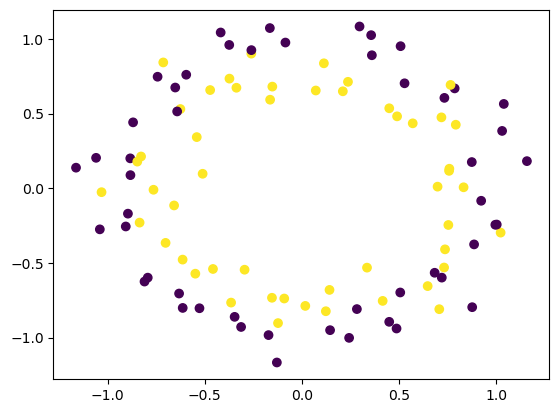

In [6]:
# Making the dataset
X,y = make_circles(n_samples=100 , noise = 0.1 , random_state=42)
plt.scatter(X[:,0] , X[:,1] , c=y , cmap='viridis')
plt.show()

In [8]:
# Let us split the data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2 , random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 2)
(20, 2)
(80,)
(20,)


In [13]:
# Let us make the Artificial Neural Network (ANN) Simple 1 hidden layer
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(256 , activation='relu' , input_dim = 2))
model.add(tf.keras.layers.Dense(1 , activation='sigmoid')) # binary classification

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

### Before Early Stopping

In [20]:
import time
model.compile(loss='binary_crossentropy' , optimizer='Adam',metrics=['accuracy'])
start = time.time()
history = model.fit(X_train,y_train , validation_data=(X_test,y_test) , epochs=3200 ,batch_size=80 , verbose=1)
print(time.time() - start)

Epoch 1/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step - accuracy: 0.8500 - loss: 0.3253 - val_accuracy: 0.7500 - val_loss: 0.4354
Epoch 2/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8500 - loss: 0.3263 - val_accuracy: 0.7500 - val_loss: 0.4456
Epoch 3/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8375 - loss: 0.3258 - val_accuracy: 0.7500 - val_loss: 0.4462
Epoch 4/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8500 - loss: 0.3258 - val_accuracy: 0.7500 - val_loss: 0.4419
Epoch 5/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8500 - loss: 0.3256 - val_accuracy: 0.7500 - val_loss: 0.4382
Epoch 6/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8500 - loss: 0.3256 - val_accuracy: 0.7500 - val_loss: 0.4378
Epoch 7/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8500 - loss: 0.3256 - val_accuracy: 0.7500 - val_loss: 0.4403
Epoch 8/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8375 - loss: 0.3256 - val_accuracy: 0.7500 - 

[]

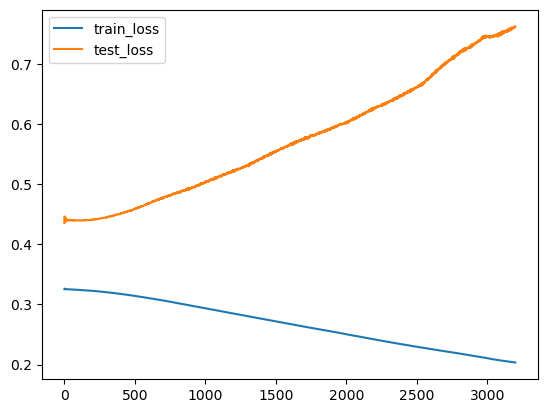

In [21]:
# Plotting the training and testing loss 
plt.plot(history.history['loss'] , label='train_loss')
plt.plot(history.history['val_loss'] , label='test_loss')
plt.legend()
plt.plot()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 5s 547us/step


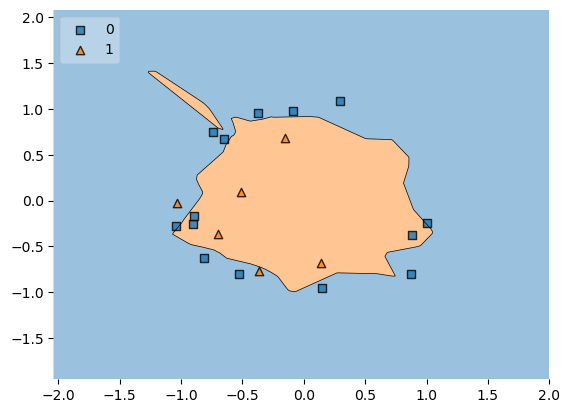

In [22]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_test , y_test.ravel() , clf = model , legend = 2)
plt.show()

### Using Early Stopping

In [29]:
callback =  tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.000001,
    patience=50,
    mode='auto',
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0
)

In [30]:
# Let us make the Artificial Neural Network (ANN) Simple 1 hidden layer
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(256 , activation='relu' , input_dim = 2))
model.add(tf.keras.layers.Dense(1 , activation='sigmoid')) # binary classification

model.summary()

c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
import time
model.compile(loss='binary_crossentropy' , optimizer='Adam',metrics=['accuracy'])
start = time.time()
history = model.fit(X_train,y_train , validation_data=(X_test,y_test) , epochs=3200 ,batch_size=80 , verbose=1 , callbacks = callback)
print(time.time() - start)

Epoch 1/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step - accuracy: 0.4875 - loss: 0.6939 - val_accuracy: 0.4000 - val_loss: 0.7046
Epoch 2/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5250 - loss: 0.6931 - val_accuracy: 0.3500 - val_loss: 0.7050
Epoch 3/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5375 - loss: 0.6922 - val_accuracy: 0.3000 - val_loss: 0.7054
Epoch 4/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5625 - loss: 0.6914 - val_accuracy: 0.3000 - val_loss: 0.7058
Epoch 5/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5500 - loss: 0.6907 - val_accuracy: 0.3000 - val_loss: 0.7060
Epoch 6/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5500 - loss: 0.6900 - val_accuracy: 0.3000 - val_loss: 0.7062
Epoch 7/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6000 - loss: 0.6892 - val_accuracy: 0.2500 - val_loss: 0.7062
Epoch 8/3200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5875 - loss: 0.6885 - val_accuracy: 0.3000 - 

[]

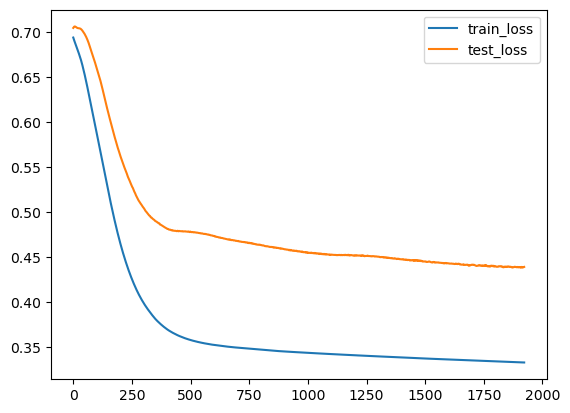

In [32]:
# Plotting the training and testing loss 
plt.plot(history.history['loss'] , label='train_loss')
plt.plot(history.history['val_loss'] , label='test_loss')
plt.legend()
plt.plot()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 5s 529us/step


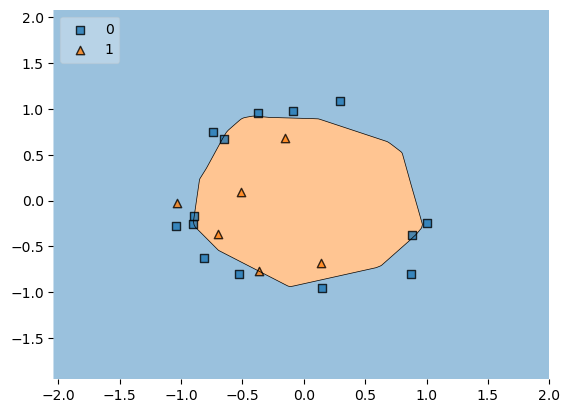

In [33]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_test , y_test.ravel() , clf = model , legend = 2)
plt.show()